In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. EDA

## 1.1 Đọc dữ liệu

In [3]:
train_df = pd.read_csv('./data/train.csv')
test_df = pd.read_csv('./data/test.csv')

## 1.2 Xem tổng quan dataset

In [4]:
train_df.shape, test_df.shape

((7352, 563), (2947, 563))

In [5]:
train_df.head()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,1,STANDING
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,1,STANDING
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118,1,STANDING
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663,1,STANDING
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892,1,STANDING


In [30]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7352 entries, 0 to 7351
Columns: 563 entries, tBodyAcc-mean()-X to Activity
dtypes: float64(561), int64(1), object(1)
memory usage: 31.6+ MB


In [7]:
train_df.describe()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject
count,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,...,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000
mean,0.274488,-0.017695,-0.109141,-0.605438,-0.510938,-0.604754,-0.630512,-0.526907,-0.606150,-0.468604,...,-0.307009,-0.625294,0.008684,0.002186,0.008726,-0.005981,-0.489547,0.058593,-0.056515,17.413085
std,0.070261,0.040811,0.056635,0.448734,0.502645,0.418687,0.424073,0.485942,0.414122,0.544547,...,0.321011,0.307584,0.336787,0.448306,0.608303,0.477975,0.511807,0.297480,0.279122,8.975143
min,-1.000000,-1.000000,-1.000000,-1.000000,-0.999873,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,-0.995357,-0.999765,-0.976580,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,1.000000
25%,0.262975,-0.024863,-0.120993,-0.992754,-0.978129,-0.980233,-0.993591,-0.978162,-0.980251,-0.936219,...,-0.542602,-0.845573,-0.121527,-0.289549,-0.482273,-0.376341,-0.812065,-0.017885,-0.143414,8.000000
50%,0.277193,-0.017219,-0.108676,-0.946196,-0.851897,-0.859365,-0.950709,-0.857328,-0.857143,-0.881637,...,-0.343685,-0.711692,0.009509,0.008943,0.008735,-0.000368,-0.709417,0.182071,0.003181,19.000000
75%,0.288461,-0.010783,-0.097794,-0.242813,-0.034231,-0.262415,-0.292680,-0.066701,-0.265671,-0.017129,...,-0.126979,-0.503878,0.150865,0.292861,0.506187,0.359368,-0.509079,0.248353,0.107659,26.000000
max,1.000000,1.000000,1.000000,1.000000,0.916238,1.000000,1.000000,0.967664,1.000000,1.000000,...,0.989538,0.956845,1.000000,1.000000,0.998702,0.996078,1.000000,0.478157,1.000000,30.000000


## 1.3 Missing Values

In [12]:
train_df.isna().sum()

tBodyAcc-mean()-X       0
tBodyAcc-mean()-Y       0
tBodyAcc-mean()-Z       0
tBodyAcc-std()-X        0
tBodyAcc-std()-Y        0
                       ..
angle(X,gravityMean)    0
angle(Y,gravityMean)    0
angle(Z,gravityMean)    0
subject                 0
Activity                0
Length: 563, dtype: int64

In [13]:
train_df.isna().sum().sum()

np.int64(0)

In [14]:
test_df.isna().sum()

tBodyAcc-mean()-X       0
tBodyAcc-mean()-Y       0
tBodyAcc-mean()-Z       0
tBodyAcc-std()-X        0
tBodyAcc-std()-Y        0
                       ..
angle(X,gravityMean)    0
angle(Y,gravityMean)    0
angle(Z,gravityMean)    0
subject                 0
Activity                0
Length: 563, dtype: int64

In [15]:
test_df.isna().sum().sum()

np.int64(0)

## 1.4 Duplicate check

In [19]:
train_df.duplicated().sum()

np.int64(0)

In [20]:
test_df.duplicated().sum()

np.int64(0)

## 1.5 Class distribution

In [21]:
train_df['Activity'].value_counts(normalize=True)

Activity
LAYING                0.191376
STANDING              0.186888
SITTING               0.174918
WALKING               0.166757
WALKING_UPSTAIRS      0.145947
WALKING_DOWNSTAIRS    0.134113
Name: proportion, dtype: float64

In [22]:
test_df['Activity'].value_counts(normalize=True)

Activity
LAYING                0.182219
STANDING              0.180523
WALKING               0.168307
SITTING               0.166610
WALKING_UPSTAIRS      0.159824
WALKING_DOWNSTAIRS    0.142518
Name: proportion, dtype: float64

## 1.6 Outlier detection

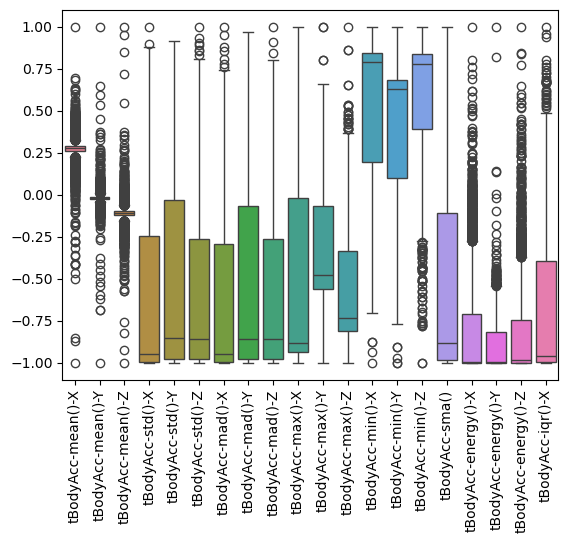

In [ ]:
sns.boxplot(data=train_df[train_df.columns[:20]], orient='v')
plt.xticks(rotation=90)
plt.show()

```text
               Dưới này là Outliers
                     o  o
                     │
             ┌───────┴───────┐ ◄─── Mốc Max (bình thường)
             │               │
             │   ┌───────┐   │ ◄─── Cạnh trên của hộp chính là Q3 (75%)
             │   │       │   │
             │   ├───────┤   │ ◄─── Đường vạch ngang giữa hộp là Q2 (Median - 50%)
             │   │       │   │
             │   └───────┘   │ ◄─── Cạnh dưới của hộp chính là Q1 (25%)
             └───────┬───────┘ ◄─── Mốc Min (bình thường)
                     │
                     o         ◄─── Trên này cũng là Outliers
```

# 2. DataPreparation

## 2.1 Data Encoding

In [54]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train = le.fit_transform(train_df['Activity'])
y_test = le.transform(test_df['Activity'])

In [ ]:

for i, label in enumerate(le.classes_):
    print(f"{i}: {label}") 

0: LAYING
1: SITTING
2: STANDING
3: WALKING
4: WALKING_DOWNSTAIRS
5: WALKING_UPSTAIRS


In [55]:
y_train, y_test

(array([2, 2, 2, ..., 5, 5, 5], shape=(7352,)),
 array([2, 2, 2, ..., 5, 5, 5], shape=(2947,)))

In [34]:
X_train = train_df.drop(columns=['Activity', 'subject'])
X_test = test_df.drop(columns=['Activity', 'subject'])

In [35]:
X_train.shape, X_test.shape

((7352, 561), (2947, 561))

## 2.2 Data Scaling

In [49]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [50]:
X_train.shape, X_test.shape

((7352, 561), (2947, 561))

In [51]:
X_train.mean(), X_train.std()

(np.float64(1.1804271735699034e-17), np.float64(1.0))

In [52]:
X_test.mean(), X_test.std()   

(np.float64(-0.011128413622992503), np.float64(0.9289333099557896))

# 3. Model Training

## 3.1 Logistic Regression

In [62]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

lr_acc = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_acc)

Logistic Regression Accuracy: 0.9548693586698337


## 3.2 Random Forest

In [64]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_acc)

Random Forest Accuracy: 0.9290804207668816


## 3.3 SVM

In [67]:
from sklearn.svm import SVC

svm_model = SVC(
    kernel='linear',
    random_state=42
)

svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)

svm_acc = accuracy_score(y_test, svm_pred)

print("SVM Accuracy:", svm_acc)

SVM Accuracy: 0.9606379368849678


# 4. Model Evaluation

## 4.1 Logistic Regression

In [68]:
from sklearn.metrics import classification_report

print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00       537
           1       0.97      0.88      0.92       491
           2       0.89      0.97      0.93       532
           3       0.94      0.99      0.97       496
           4       0.99      0.94      0.96       420
           5       0.96      0.95      0.95       471

    accuracy                           0.95      2947
   macro avg       0.96      0.95      0.95      2947
weighted avg       0.96      0.95      0.95      2947



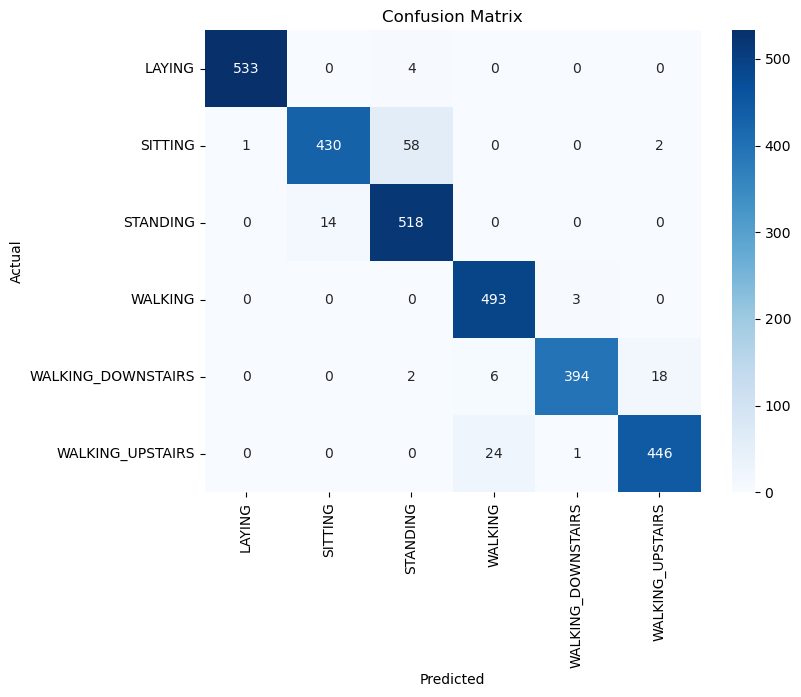

In [88]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_lr = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    cmap='Blues', 
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()



In [83]:
train_acc_lr = lr_model.score(X_train, y_train)

test_acc_lr = lr_model.score(X_test, y_test)

print("Train Accuracy (LR):", train_acc_lr)
print("Test Accuracy (LR):", test_acc_lr)

Train Accuracy (LR): 0.9964635473340587
Test Accuracy (LR): 0.9548693586698337


## 4.2 Random Forest

In [71]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       537
           1       0.92      0.89      0.90       491
           2       0.90      0.92      0.91       532
           3       0.91      0.96      0.93       496
           4       0.96      0.86      0.91       420
           5       0.90      0.92      0.91       471

    accuracy                           0.93      2947
   macro avg       0.93      0.93      0.93      2947
weighted avg       0.93      0.93      0.93      2947



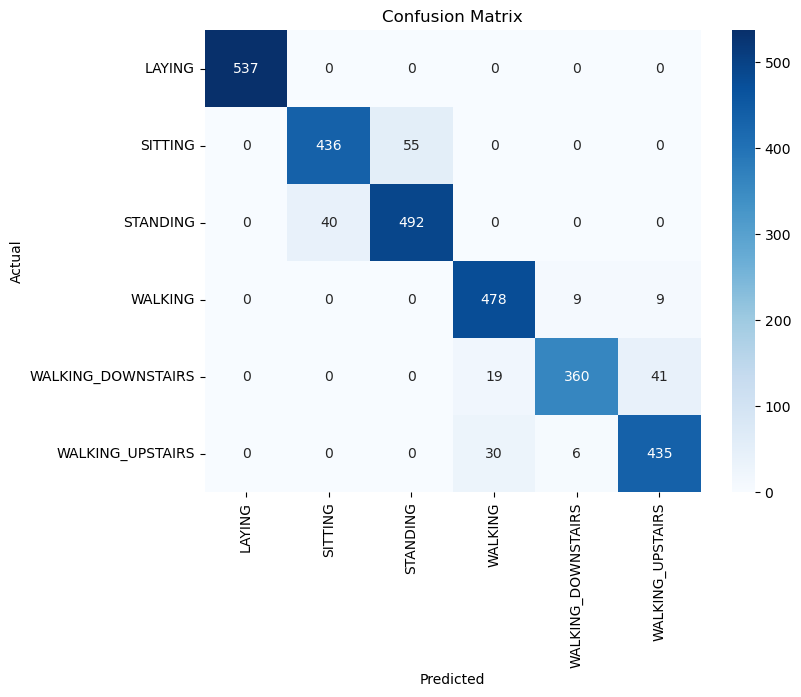

In [89]:
cm_rf = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [84]:
train_acc_rf = rf_model.score(X_train, y_train)
test_acc_rf = rf_model.score(X_test, y_test)

print("Train Accuracy (RF):", train_acc_rf)
print("Test Accuracy (RF):", test_acc_rf)

Train Accuracy (RF): 1.0
Test Accuracy (RF): 0.9290804207668816


## 4.3 SVM

In [81]:
print(classification_report(y_test, svm_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       537
           1       0.96      0.88      0.92       491
           2       0.90      0.97      0.93       532
           3       0.96      1.00      0.98       496
           4       0.99      0.95      0.97       420
           5       0.97      0.96      0.96       471

    accuracy                           0.96      2947
   macro avg       0.96      0.96      0.96      2947
weighted avg       0.96      0.96      0.96      2947



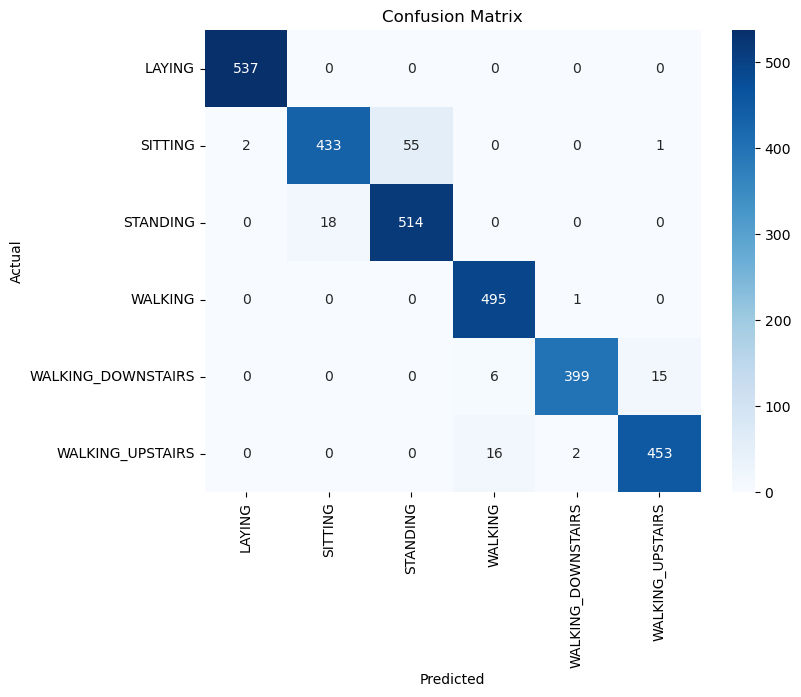

In [90]:
cm_svm = confusion_matrix(y_test, svm_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm_svm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [85]:
train_acc_svm = svm_model.score(X_train, y_train)
test_acc_svm = svm_model.score(X_test, y_test) 

print("Train Accuracy (SVM):", train_acc_svm)
print("Test Accuracy (SVM):", test_acc_svm)

Train Accuracy (SVM): 0.9968715995647442
Test Accuracy (SVM): 0.9606379368849678
